# IOOS Data

The Integrated Ocean Observing System (IOOS) collects two chlorophyll variables:
- mass_concentration_of_chlorophyll_in_sea_water
- mass_fraction_of_chlorophyll_a_in_sea_water

Based on research into their extensive QA/QC methods, mass_fraction_of_chlorophyll_a_in_sea_water is in-vivo, flourecence chlorophyll, so this variable is not collected. 

All data is organized and compiled from the IOOS ERDDAP database. Since these datasets are usually very large due to the regular samples, the datasets are organized into regions for better processing speeds. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [ ]:
#Seperate datasets into regions for easier manegment 
#boundries for west coast
kwest  = {"min_lon": -131, "max_lon": -111,
    "min_lat": 19,"max_lat": 53,
    "min_time": "2000-01-01T00:00:00Z",
    "max_time": "2025-04-28T00:00:00Z"}
#boundries for east coast
keast  = {"min_lon": -82, "max_lon": -47,
    "min_lat": 19, "max_lat": 50,
    "min_time": "2000-01-01T00:00:00Z",
    "max_time": "2025-04-28T00:00:00Z"}
#boundries for gulf of mexico
kgulf  = {"min_lon": -103, "max_lon": -82,
    "min_lat": 17,"max_lat": 34,
    "min_time": "2000-01-01T00:00:00Z",
    "max_time": "2025-04-28T00:00:00Z"}

#boundries for alaska
kalas  = {"min_lon": -168, "max_lon": -135,
    "min_lat": 51,"max_lat": 77,
    "min_time": "2000-01-01T00:00:00Z",
    "max_time": "2025-04-28T00:00:00Z"}
#boundries for hawaii
khaw  = {"min_lon": -162, "max_lon": -150,
    "min_lat": 15, "max_lat": 23,
    "min_time": "2000-01-01T00:00:00Z",
    "max_time": "2025-04-28T00:00:00Z"}

Using the ERDDAP server, the variable name mass_concentration_of_chlorophyll_in_sea_water was searched. Any projects with that variable was saved in each region

In [ ]:
server = "http://erddap.sensors.ioos.us/erddap" #ioos erddap server
e = ERDDAP(server=server, protocol="tabledap")
url_west = e.get_search_url(search_for="mass_concentration_of_chlorophyll_in_sea_water", response="csv",**kwest) #only pull chlorophyll data from within the boundries
url_east = e.get_search_url(search_for="mass_concentration_of_chlorophyll_in_sea_water", response="csv",**keast) 
url_gulf = e.get_search_url(search_for="mass_concentration_of_chlorophyll_in_sea_water", response="csv",**kgulf) 
url_alas = e.get_search_url(search_for="mass_concentration_of_chlorophyll_in_sea_water", response="csv",**kalas) 
url_haw = e.get_search_url(search_for="mass_concentration_of_chlorophyll_in_sea_water", response="csv",**khaw) 

#read each url in
dfs_east = pd.read_csv(url_east)
dfs_west = pd.read_csv(url_west)
dfs_gulf = pd.read_csv(url_gulf)
dfs_alas = pd.read_csv(url_alas)
dfs_haw = pd.read_csv(url_haw)

#initialize regional dataframes to loop throug
dataframes_east = {}
dataframes_west = {}
dataframes_gulf = {}
dataframes_ak = {}
dataframes_haw = {}

reg_names = ['dataframes_east','dataframes_west','dataframes_gulf','dataframes_ak','dataframes_haw'] #create a dataframe for each region 
df_names = ['dfs_east','dfs_west','dfs_gulf','dfs_alas','dfs_haw']

Each variable in the list 'df_names' holds the ERDDAP information for each project in the region that has chlorophyll data. For example, this is what dfs_haw looks like:

![ioos_dfshaw](images/dfs_haw.png)

For each 'Dataset ID' in the dfs (for example, in dfs_haw, for the 4 Dataset IDs compiled), the variables time, lat, lon, depth, chlorophyll, and chlorophyll flags are compiled to that project's dataframe along with metadata. The dataframe is then added to the dictionarys in reg_names

In [ ]:
for idx2 in range(len(reg_names)): #for each reg_name
    print('region '+reg_names[idx2]) 
    for idx, row in globals()[df_names[idx2]].iterrows(): #for every project in the df_names
        dataset_id = row['Dataset ID'] #identify the id
        e.dataset_id = dataset_id #match the id with the e dictionary
        e.variables = ['time', 'latitude', 'longitude', 'mass_concentration_of_chlorophyll_in_sea_water',
                       'z','mass_concentration_of_chlorophyll_in_sea_water_qc_agg']  #only append these variables
        try:
            print(f"Loading {dataset_id}...")
            df_data = e.to_pandas(index_col="time (UTC)") #create dataframe from e indexing the time
            globals()[reg_names[idx2]][dataset_id] = df_data #add the dataframe to the reg_name by id
            #add these to dataframe to ensure metadata is recorded
            globals()[reg_names[idx2]][dataset_id]['Dataset ID'] = dataset_id #add a column for dataset id
            globals()[reg_names[idx2]][dataset_id]['source'] = 'IOOS' #add source column
            globals()[reg_names[idx2]][dataset_id]['Institution'] = row['Institution'] #add institude column
            globals()[reg_names[idx2]][dataset_id]['url'] = row['Background Info'] #add link to sensor website
            globals()[reg_names[idx2]][dataset_id]['experiment'] = row['Title'] #add project to dataset

            time.sleep(1)  # small delay to avoid hammering the server
        except Exception as ex:
            print(f"Failed to load {dataset_id}: {ex}") #if no chlorophyll in the dataset, this allows it to skip those


After running the code above, each region should now have a dictionary holding each IOOS project's dataframe. Here's an example of what the variable dataframes_haw looks like 

![ioos_dfhaw](images/dataframes_haw.png)

Next, rename the columns in each dataframe to match SeaBASS columns and overall be more managable, and remove all suspect chlorophyll data. 

In [ ]:
for idx2 in range(len(reg_names)):    
    for dsid, df in globals()[reg_names[idx2]].items():
        df = df.reset_index()
        df = df.rename(columns={'latitude (degrees_north)': 'lat','longitude (degrees_east)': 'lon',
            'mass_concentration_of_chlorophyll_in_sea_water (microg.L-1)': 'chl', #micro gram/L == mg/m^3, so same units as seabass
            'mass_concentration_of_chlorophyll_in_sea_water_qc_agg': 'chl_qc_t','z (m)': 'depth', 'time (UTC)':'datetime'})
        df.datetime=pd.to_datetime(df.datetime.astype(str),format='mixed')
        #remove bad flags
        df = df[df['chl_qc_t'] != 3] #remove all 3s from dataframe i.e suspect points
        df = df[df['chl_qc_t'] != 4] #remove all 4s from dataframe i.e. failed points 

        globals()[reg_names[idx2]][dsid] = df  #update the dict

Since IOOS is a data repository, where extracted chlorophyll data is mixed in with in vivo estimated chlorophyll, we'll add a data_type_flag to help determind if the sample resolution is high enough to be suspicious. 

In [ ]:
#create time and depth flags
for idx2 in range(len(reg_names)): #for every region's dataframe
    for dsid, df in globals()[reg_names[idx2]].items(): #for every dataframe in the region   
        df = df.sort_values(by='datetime')
        df['t_flag']=0 #initialize temporal resolution flag, 0=good, 1= bad (less than 1hour),2=flag (time is 0 i.e repeated)
        df['diff_time'] = 0 #column to populate with datatypes as values for organization
        df['d_flag'] = 0 #initialize depth flag, 0=good, 1=bad (less than 5m), 2=flag
        df['decision'] = 2 #ultimate decision flag inidcating whether to keep or toss data point (0=good, 1=bad,2=flag)
        
        df['diff_time']= df['datetime'].diff()      
        df.t_flag=np.where(df['diff_time']< pd.to_timedelta('10 minutes'), 1, df.t_flag) #if delta t is less than 1 hour, flag as bad
        df.t_flag=np.where(df['diff_time']== pd.to_timedelta(0), 2, df.t_flag) #if 0, then just a repeat so not necessarily bad       
        if 'depth' in df.columns: #find average change in depth
            depth_diff =abs(df.depth.diff())#calculate absolute change in depth
            df.loc[df[depth_diff<1].index,'d_flag']=1 #if the change in depth is not large enough
            df.loc[df[depth_diff==0].index,'d_flag']=2 #if the change in depth doesn't move, set as 2, diff_time 
        else:
            avg_z_res = None
            
        df.decision[(df['t_flag'] ==0) & (df['d_flag']==0)] = 0 #if both good, then good
        df.decision[(df['t_flag'] ==0) & (df['d_flag']==1)] = 1 #if everything else is good but the depth is too short, flag as nad
        df.decision[(df['t_flag'] ==0) & (df['d_flag']==2)] = 0 #if everything else is good and depth repeats, good
        df.decision[(df['t_flag'] ==1) & (df['d_flag']==0)] = 1 #IF TIME IS EVER BAD then the whole thing is bad
        df.decision[(df['t_flag'] ==1) & (df['d_flag']==1)] = 1
        df.decision[(df['t_flag'] ==1) & (df['d_flag']==2)] = 1
        df.decision[(df['t_flag'] ==2) & (df['d_flag']==0)] = 0
        df.decision[(df['t_flag'] ==2) & (df['d_flag']==1)] = 1
        df.decision[(df['t_flag'] ==2) & (df['d_flag']==2)] = 1
            
        globals()[reg_names[idx2]][dsid] = df  #update the dict

As mentioned above, these dataframes are very large. IOOS is once of the most comprehensive oceanographic data repositories and some of these project record full water column data every day for the past 30 years. Since this algorithm does not need this temporal resolution, the dataframes can be reduced to only the top 10 meters and averaged to 1 day values. Only then can the dictionary of dataframes be turned into a dataframe without breaking the code. 

In [ ]:
for idx2 in range(len(reg_names)):    
    for dsid, df in globals()[reg_names[idx2]].items(): 
        df=df[(df['depth']>=-10) & (df['depth']<=10)] #only within top 10 meters
        df['date'] = df['datetime'].dt.date
        df = df.drop(columns='datetime')
        df=df.groupby(['date','Dataset ID','source','Institution','url','experiment']).mean() #groupby date and take average
        globals()[reg_names[idx2]][dsid] = df.reset_index()

#turn the dictionary of dataframes into 1 single dataframe with all values concatinated 
dataframes_east = pd.concat(dataframes_east.values(), ignore_index=True)
dataframes_west = pd.concat(dataframes_west.values(), ignore_index=True)
dataframes_gulf = pd.concat(dataframes_gulf.values(), ignore_index=True)
dataframes_haw = pd.concat(dataframes_haw.values(), ignore_index=True)
dataframes_ak = pd.concat(dataframes_ak.values(), ignore_index=True)
dfs=[dataframes_east,dataframes_west,dataframes_gulf,dataframes_haw,dataframes_ak]


In [ ]:
ioos_chl = pd.concat(dfs).reset_index(drop=True) #concatinate them all together 
ioos_chl=ioos_chl[['date', 'lat', 'lon', 'chl', 'depth','source','Dataset ID','Institution','url', 'experiment']]
ioos_chl['date'] = pd.to_datetime(ioos_chl['date'])
ioos_chl = ioos_chl.loc[ioos_chl['date'] > '2000-01-01'] #only want dates post 2000 for this algorithm 
#remove any negative chl values
ioos_chl=ioos_chl[(ioos_chl['chl']>0)]

Due to the high number of projects and locations, many times chlorophyll values extremely large which can lead to some questionable data. For example, Dataset ID gov_usgs_nwis_01304562 has many datapoints in the 200,000 mg/L. And so, remove the top 5% quantile of the data before matching with seabass. 

In [ ]:
Q1 = ioos_chl['chl'].quantile(0.05) 
Q3 = ioos_chl['chl'].quantile(0.95)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
ioos_chl2 = ioos_chl[ioos_chl['chl'] <= upper_bound] #only keep chl data below the upper bound

In [ ]:
ioos_chl2['HPLC'] = 1 #there's no definitive way of distinguishing between hplc, so assume no
ioos_chl2['triplicate'] = 1 #since i'm reducing to shallow, 1 day average, triplicate flag = 1 (no triplicate)

There are 2 projects that still don't have lat and lon values, so manually look up the location and add to the dataframe

In [ ]:
ioos_chl2.loc[ioos_chl2['Dataset ID'] == 'pivers-island-coastal-observa', ['lat', 'lon']] = [34.7181, -76.6707]
ioos_chl2.loc[ioos_chl2['Dataset ID'] == 'mlml_monterey', ['lat', 'lon']] = [36.60513, -121.88935]

Done with IOOS yay!

## Plots

In [2]:
IOOS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\ioos_chl_qc2.xlsx')

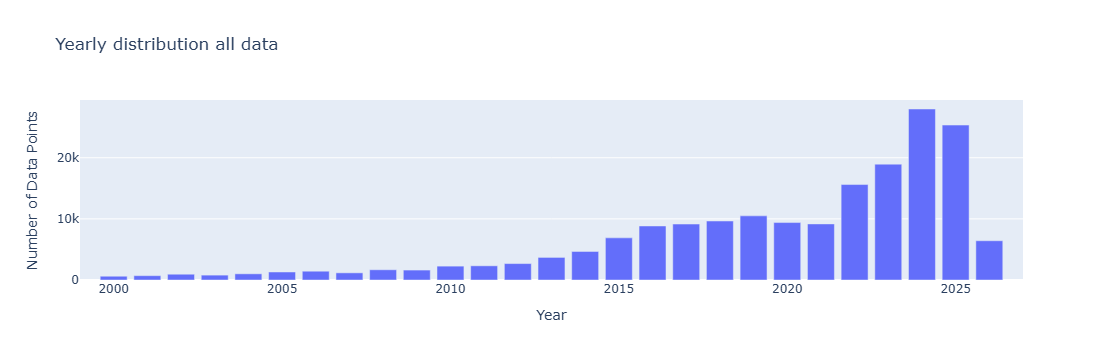

In [3]:
year_test=IOOS.copy()
year_test['date'] = pd.to_datetime(year_test['date'])
year_test['year'] = year_test['date'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

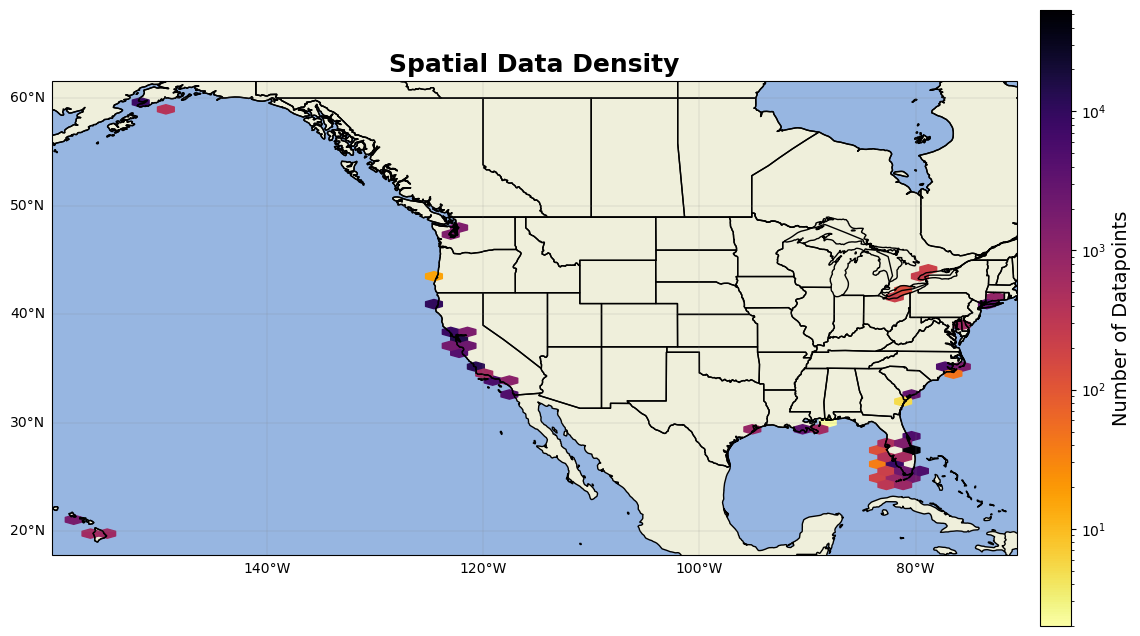

In [7]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=55, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()